In [36]:
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
# Read in afli_data1.csv, afli_data2.csv, and afli_data3.csv, and combine them into a single DataFrame
df1 = pd.read_csv('afli_data1.csv')
df2 = pd.read_csv('afli_data2.csv')
df3 = pd.read_csv('afli_data3.csv')
combined_df = pd.concat([df1, df2, df3], ignore_index=True)
# Display the combined DataFrame
combined_df.head()

,Unnamed: 0,Fisktegund,Löndunarhöfn,Eining,Ár,Mánuður,"Afli og aflaverðmæti eftir fisktegund, löndunarhöfn, landsvæðum og mánuðum 1982-2024"
0,0,Þorskur,Akranes,Magn,1982,janúar,469
1,1,Þorskur,Akranes,Magn,1982,febrúar,924
2,2,Þorskur,Akranes,Magn,1982,mars,2262
3,3,Þorskur,Akranes,Magn,1982,apríl,1420
4,4,Þorskur,Akranes,Magn,1982,maí,877


In [38]:
# Delete the "Unnamed: 0" column from the combined DataFrame
combined_df.drop(columns=['Unnamed: 0'], inplace=True)
# Change name of "Afli og aflaverðmæti eftir fisktegund, löndunarhöfn, landsvæðum og mánuðum 1982-2024" column to "Afli"
combined_df.rename(columns={'Afli og aflaverðmæti eftir fisktegund, löndunarhöfn, landsvæðum og mánuðum 1982-2024': 'Afli'}, inplace=True)
# Display the combined DataFrame
combined_df.head()
len(combined_df)

4188888

In [39]:
# Delete rows where "Löndunarhöfn" is "A.-Þýskaland", "Bandaríkin", "Belgía", "Bretland", "Danmörk", "Domeniska Lýðveldið", "Frakkland", "Færeyjar", "Grænland", "Holland", "Írland", "Japan", "Kanada", "Litháen", "Namibía", "Noregur", "Skotland", "Spánn", "Svíþjóð", "Tyrkland", "Þýskaland" and "Önnur löndun"
combined_df = combined_df[~combined_df['Löndunarhöfn'].isin(['A.-Þýskaland', 'Bandaríkin', 'Belgía', 'Bretland', 'Danmörk', 'Domeniska Lýðveldið', 'Frakkland', 'Færeyjar', 'Grænland', 'Holland', 'Írland', 'Japan', 'Kanada', 'Litháen', 'Namibía', 'Noregur', 'Skotland', 'Spánn', 'Svíþjóð', 'Tyrkland', 'Þýskaland', 'Önnur löndun'])]
# Display length of combined DataFrame
len(combined_df)

3383928

In [40]:
# Keep only rows where "Fisktegund" is "Þorskur", "Ýsa", "Síld", "Loðna" and "Makríll"
combined_df = combined_df[combined_df['Fisktegund'].isin(['Þorskur', 'Ýsa', 'Síld', 'Loðna', 'Makríll'])]
# Display length of combined DataFrame
len(combined_df)

417960

In [41]:
# Convert Mánuður to numeric values
combined_df['Mánuður'] = combined_df['Mánuður'].map({
    'janúar': 1,
    'febrúar': 2,
    'mars': 3,
    'apríl': 4,
    'maí': 5,
    'júní': 6,
    'júlí': 7,
    'ágúst': 8,
    'september': 9,
    'október': 10,
    'nóvember': 11,
    'desember': 12
})  
# Display the transformed DataFrame
combined_df.head()

,Fisktegund,Löndunarhöfn,Eining,Ár,Mánuður,Afli
0,Þorskur,Akranes,Magn,1982,1,469
1,Þorskur,Akranes,Magn,1982,2,924
2,Þorskur,Akranes,Magn,1982,3,2262
3,Þorskur,Akranes,Magn,1982,4,1420
4,Þorskur,Akranes,Magn,1982,5,877


In [42]:
# Convert "Afli" to integer, and fill NaN values with 0
combined_df['Afli'] = pd.to_numeric(combined_df['Afli'], errors='coerce').fillna(0).astype(int)
# Fill values in "Afli" that are ".." with 0
combined_df['Afli'] = combined_df['Afli'].replace('..', 0)


In [43]:
# Pivot the dataframe so that values in "Eining" become separate columns ("Magn" and "Verðmæti")

combined_df = (
    combined_df
    .pivot_table(
        index=["Fisktegund", "Löndunarhöfn", "Ár", "Mánuður"],
        columns="Eining",
        values="Afli",
        aggfunc="first"   
    )
    .reset_index()
)

# Remove the column index name
combined_df.columns.name = None

In [44]:
# Translate column names to English
combined_df.rename(columns={
    'Fisktegund': 'Species',
    'Löndunarhöfn': 'Port',
    'Ár': 'Year',
    'Mánuður': 'Month',
    'Magn': 'Quantity',
    'Verðmæti': 'Value'
}, inplace=True)
# Translate values in "Species" column to English
combined_df['Species'] = combined_df['Species'].map({
    'Þorskur': 'Cod',
    'Ýsa': 'Haddock',
    'Síld': 'Herring',
    'Loðna': 'Capelin',
    'Makríll': 'Mackerel'
})
# Display the transformed DataFrame
combined_df.head()

,Species,Port,Year,Month,Quantity,Value
0,Capelin,Akranes,1982,1,0,0
1,Capelin,Akranes,1982,2,0,0
2,Capelin,Akranes,1982,3,0,0
3,Capelin,Akranes,1982,4,0,0
4,Capelin,Akranes,1982,5,0,0


In [45]:
# # Create copies of 1989 and 1991 data
# df_1989 = combined_df[combined_df["Ár"] == 1989].copy()
# df_1991 = combined_df[combined_df["Ár"] == 1991].copy()

# # Merge matching rows from 1989 and 1991
# df_1990 = df_1989.merge(
#     df_1991,
#     on=["Fisktegund", "Löndunarhöfn", "Mánuður"],
#     suffixes=("_1989", "_1991")
# )

# # Create 1990 values as the mean of 1989 and 1991
# df_1990["Ár"] = 1990

# df_1990["Magn"] = (
#     df_1990["Magn_1989"] + df_1990["Magn_1991"]
# ) / 2

# df_1990["Verðmæti"] = (
#     df_1990["Verðmæti_1989"] + df_1990["Verðmæti_1991"]
# ) / 2

# # Keep only needed columns
# df_1990 = df_1990[
#     ["Fisktegund", "Löndunarhöfn", "Ár", "Mánuður", "Magn", "Verðmæti"]
# ]

# # Remove any existing 1990 rows (if there are any)
# combined_df = combined_df[combined_df["Ár"] != 1990]

# # Add the new interpolated 1990 rows
# combined_df = pd.concat([combined_df, df_1990], ignore_index=True)

# # Optional: sort dataframe
# combined_df = combined_df.sort_values(
#     ["Fisktegund", "Löndunarhöfn", "Ár", "Mánuður"]
# ).reset_index(drop=True)

In [46]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Create dictionaries with the known TOTAL 1990 values
#    for each species and month
# ------------------------------------------------------------

# Example structure:
# totals_1990_quantity[(species, month)] = total quantity
# totals_1990_value[(species, month)] = total value

totals_1990_quantity = {
    ("Cod", 1): 23462, ("Cod", 2): 29486, ("Cod", 3): 47340, ("Cod", 4): 40832,
    ("Cod", 5): 32471, ("Cod", 6): 20675, ("Cod", 7): 38747, ("Cod", 8): 23758,
    ("Cod", 9): 17636, ("Cod", 10): 15431, ("Cod", 11): 21941, ("Cod", 12): 21581,
    
    ("Haddock", 1): 2592, ("Haddock", 2): 4637, ("Haddock", 3): 4396, ("Haddock", 4): 9141,
    ("Haddock", 5): 10106, ("Haddock", 6): 5786, ("Haddock", 7): 6058, ("Haddock", 8): 6157,
    ("Haddock", 9): 3431, ("Haddock", 10): 4677, ("Haddock", 11): 5374, ("Haddock", 12): 3650,
    
    ("Herring", 1): 2289, ("Herring", 2): 0, ("Herring", 3): 0, ("Herring", 4): 0,
    ("Herring", 5): 0, ("Herring", 6): 0, ("Herring", 7): 0, ("Herring", 8): 0,
    ("Herring", 9): 22, ("Herring", 10): 20270, ("Herring", 11): 50579, ("Herring", 12): 17177,
    
    ("Capelin", 1): 196491, ("Capelin", 2): 282822, ("Capelin", 3): 124727, ("Capelin", 4): 4044,
    ("Capelin", 5): 0, ("Capelin", 6): 0, ("Capelin", 7): 0, ("Capelin", 8): 0,
    ("Capelin", 9): 0, ("Capelin", 10): 23329, ("Capelin", 11): 55243, ("Capelin", 12): 5083,
    
    ("Mackerel", 1): 0, ("Mackerel", 2): 0, ("Mackerel", 3): 0, ("Mackerel", 4): 0,
    ("Mackerel", 5): 0, ("Mackerel", 6): 0, ("Mackerel", 7): 0, ("Mackerel", 8): 0,
    ("Mackerel", 9): 0, ("Mackerel", 10): 0, ("Mackerel", 11): 0, ("Mackerel", 12): 0,
}

totals_1990_value = {
    ("Cod", 1): 1348913, ("Cod", 2): 1701766, ("Cod", 3): 2702640, ("Cod", 4): 2391058,
    ("Cod", 5): 1802447, ("Cod", 6): 1126921, ("Cod", 7): 2220279, ("Cod", 8): 1561079,
    ("Cod", 9): 1153519, ("Cod", 10): 1085385, ("Cod", 11): 1487562, ("Cod", 12): 1510972,
    
    ("Haddock", 1): 224107, ("Haddock", 2): 491242, ("Haddock", 3): 370304, ("Haddock", 4): 699268,
    ("Haddock", 5): 713785, ("Haddock", 6): 430081, ("Haddock", 7): 487602, ("Haddock", 8): 537779,
    ("Haddock", 9): 323019, ("Haddock", 10): 436087, ("Haddock", 11): 473582, ("Haddock", 12): 343753,
    
    ("Herring", 1): 29812, ("Herring", 2): 0, ("Herring", 3): 0, ("Herring", 4): 0,
    ("Herring", 5): 0, ("Herring", 6): 0, ("Herring", 7): 0, ("Herring", 8): 1,
    ("Herring", 9): 2375, ("Herring", 10): 192704, ("Herring", 11): 435181, ("Herring", 12): 150912,
    
    ("Capelin", 1): 779798, ("Capelin", 2): 1078660, ("Capelin", 3): 366382, ("Capelin", 4): 124,
    ("Capelin", 5): 0, ("Capelin", 6): 0, ("Capelin", 7): 0, ("Capelin", 8): 0,
    ("Capelin", 9): 0, ("Capelin", 10): 110732, ("Capelin", 11): 216461, ("Capelin", 12): 22189,
    
    ("Mackerel", 1): 0, ("Mackerel", 2): 0, ("Mackerel", 3): 0, ("Mackerel", 4): 0,
    ("Mackerel", 5): 0, ("Mackerel", 6): 0, ("Mackerel", 7): 0, ("Mackerel", 8): 0,
    ("Mackerel", 9): 0, ("Mackerel", 10): 0, ("Mackerel", 11): 0, ("Mackerel", 12): 0,
}

# ------------------------------------------------------------
# 2. Calculate each port's share in 1989
# ------------------------------------------------------------

df_1989 = combined_df[combined_df["Year"] == 1989].copy()

# Total by species/month in 1989
totals_1989 = (
    df_1989
    .groupby(["Species", "Month"])[["Quantity", "Value"]]
    .sum()
    .rename(columns={
        "Quantity": "TotalQuantity1989",
        "Value": "TotalValue1989"
    })
    .reset_index()
)

# Merge totals back onto 1989 dataframe
df_1989 = df_1989.merge(
    totals_1989,
    on=["Species", "Month"],
    how="left"
)

# Calculate port shares
df_1989["QuantityShare"] = (
    df_1989["Quantity"] / df_1989["TotalQuantity1989"]
)

df_1989["ValueShare"] = (
    df_1989["Value"] / df_1989["TotalValue1989"]
)

# Keep only needed columns
shares_1989 = df_1989[[
    "Species",
    "Port",
    "Month",
    "QuantityShare",
    "ValueShare"
]]

# ------------------------------------------------------------
# 3. Fill missing 1990 values using 1989 percentages
# ------------------------------------------------------------

mask_1990 = combined_df["Year"] == 1990

for idx, row in combined_df[mask_1990].iterrows():

    species = row["Species"]
    port = row["Port"]
    month = row["Month"]

    # Find 1989 share for this port/species/month
    share_row = shares_1989[
        (shares_1989["Species"] == species) &
        (shares_1989["Port"] == port) &
        (shares_1989["Month"] == month)
    ]

    if len(share_row) == 0:
        continue

    quantity_share = share_row["QuantityShare"].iloc[0]
    value_share = share_row["ValueShare"].iloc[0]

    # Known 1990 totals
    total_quantity_1990 = totals_1990_quantity.get((species, month), np.nan)
    total_value_1990 = totals_1990_value.get((species, month), np.nan)

    # Fill values ONLY where current value is 0
    # Fill Quantity
    if (
        row["Quantity"] == 0
        and pd.notna(total_quantity_1990)
        and pd.notna(quantity_share)
    ):
        combined_df.at[idx, "Quantity"] = int(
            round(quantity_share * total_quantity_1990)
        )

    # Fill Value
    if (
        row["Value"] == 0
        and pd.notna(total_value_1990)
        and pd.notna(value_share)
    ):
        combined_df.at[idx, "Value"] = int(
            round(value_share * total_value_1990)
        )

# ------------------------------------------------------------
# 4. Make sure columns are integers
# ------------------------------------------------------------

combined_df["Quantity"] = combined_df["Quantity"].astype(int)
combined_df["Value"] = combined_df["Value"].astype(int)

### Create yearly dataframe

In [47]:
# Create a yearly dataframe by summing over all months

df_yearly = (
    combined_df
    .groupby(
        ["Species", "Port", "Year"],
        as_index=False
    )[["Quantity", "Value"]]
    .sum()
)

In [48]:
# Sum of "Quantity" and "Value" columns for all rows where "Year" is 1990
df_1990 = df_yearly[df_yearly['Year'] == 1990]
total_quantity_1990 = df_1990['Quantity'].sum()
total_value_1990 = df_1990['Value'].sum()
print(f"Total Quantity in 1990: {total_quantity_1990}")
print(f"Total Value in 1990: {total_value_1990}")

Total Quantity in 1990: 1181441
Total Value in 1990: 29006107


## Plots

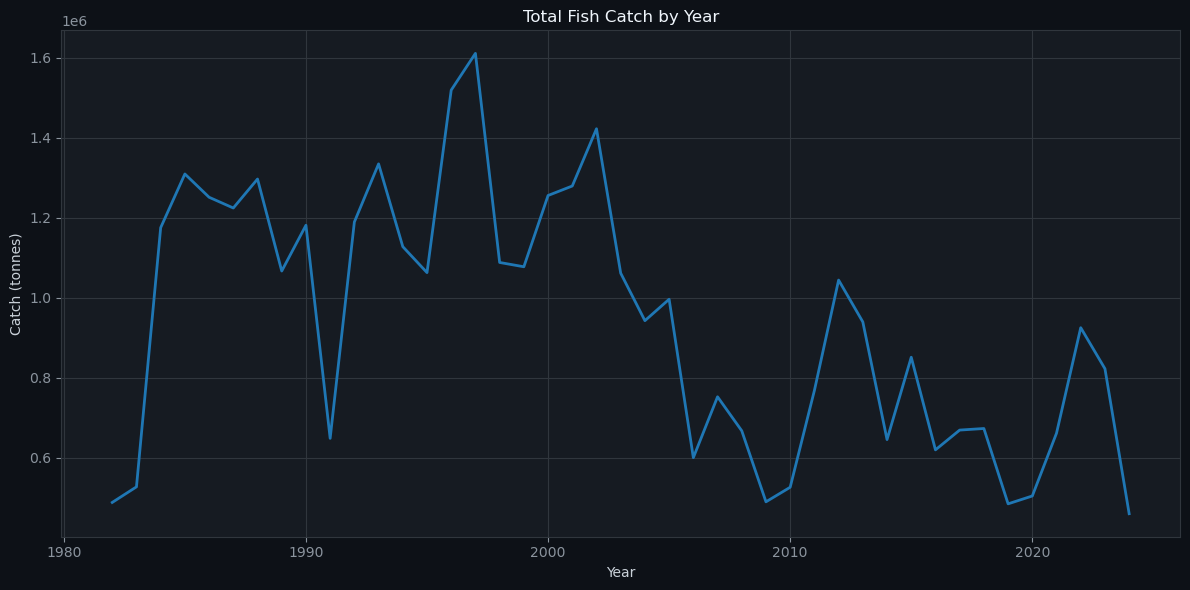

In [49]:
yearly_total = (
    df_yearly
    .groupby("Year", as_index=False)["Quantity"]
    .sum()
)

plt.figure(figsize=(12, 6))
plt.plot(yearly_total["Year"], yearly_total["Quantity"], linewidth=2)

plt.title("Total Fish Catch by Year")
plt.xlabel("Year")
plt.ylabel("Catch (tonnes)")
plt.grid(True)

plt.tight_layout()
plt.show()

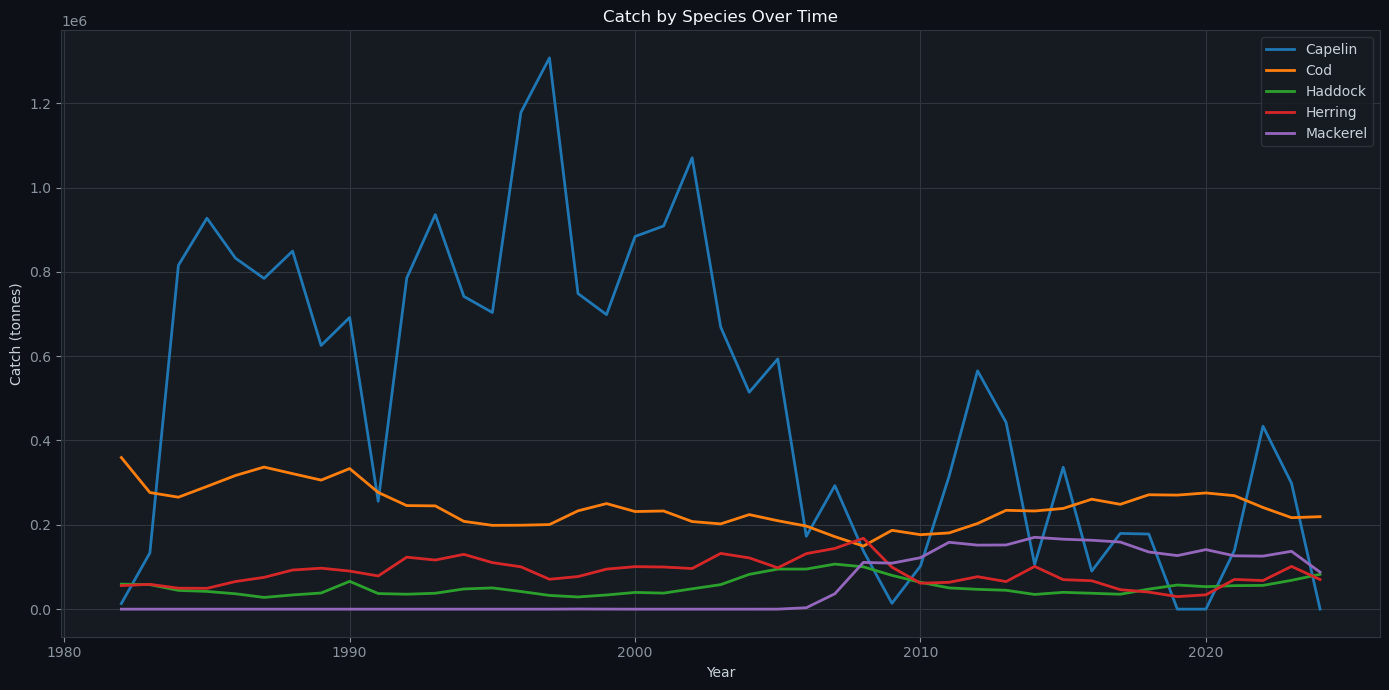

In [50]:
species_yearly = (
    df_yearly
    .groupby(["Year", "Species"], as_index=False)["Quantity"]
    .sum()
)

pivot_species = species_yearly.pivot(
    index="Year",
    columns="Species",
    values="Quantity"
)

plt.figure(figsize=(14, 7))

for col in pivot_species.columns:
    plt.plot(
        pivot_species.index,
        pivot_species[col],
        linewidth=2,
        label=col
    )

plt.title("Catch by Species Over Time")
plt.xlabel("Year")
plt.ylabel("Catch (tonnes)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

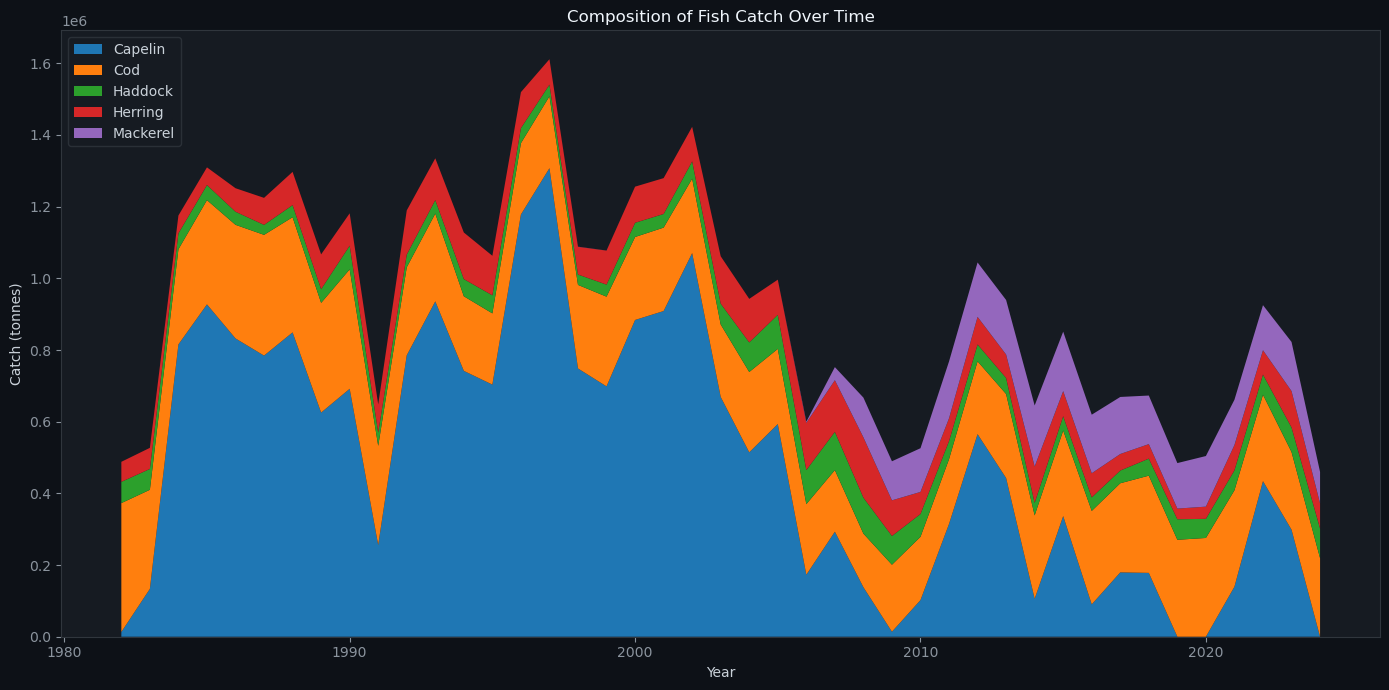

In [51]:
plt.figure(figsize=(14, 7))

plt.stackplot(
    pivot_species.index,
    pivot_species.T,
    labels=pivot_species.columns
)

plt.title("Composition of Fish Catch Over Time")
plt.xlabel("Year")
plt.ylabel("Catch (tonnes)")
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

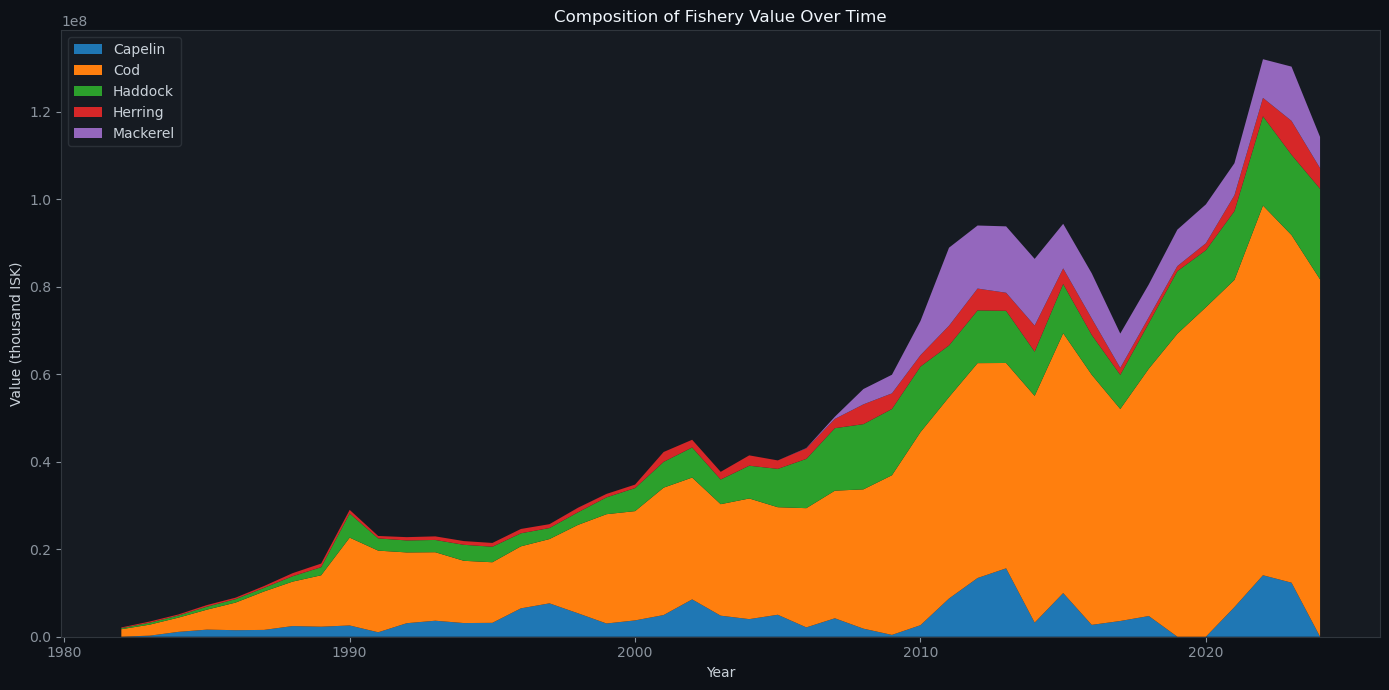

In [52]:
# Value by species and year
species_value_yearly = (
    df_yearly
    .groupby(["Year", "Species"], as_index=False)["Value"]
    .sum()
)

pivot_value = species_value_yearly.pivot(
    index="Year",
    columns="Species",
    values="Value"
).fillna(0)

plt.figure(figsize=(14, 7))

plt.stackplot(
    pivot_value.index,
    pivot_value.T,
    labels=pivot_value.columns
)

plt.title("Composition of Fishery Value Over Time")
plt.xlabel("Year")
plt.ylabel("Value (thousand ISK)")
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

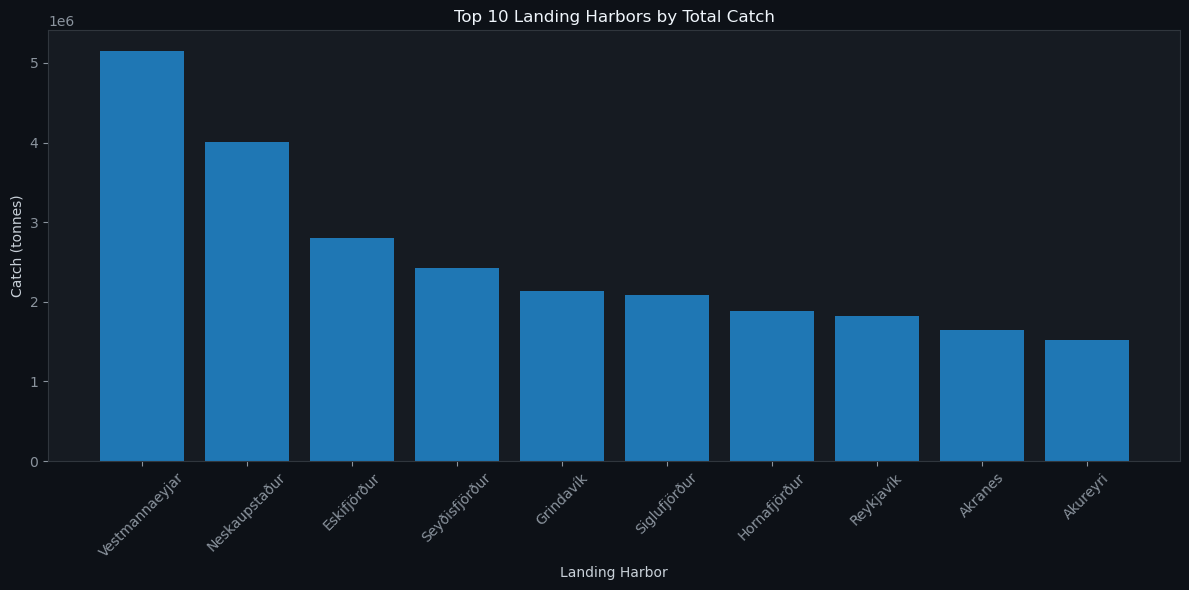

In [53]:
top_harbors = (
    df_yearly
    .groupby("Port", as_index=False)["Quantity"]
    .sum()
    .sort_values("Quantity", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_harbors["Port"],
    top_harbors["Quantity"]
)

plt.title("Top 10 Landing Harbors by Total Catch")
plt.xlabel("Landing Harbor")
plt.ylabel("Catch (tonnes)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

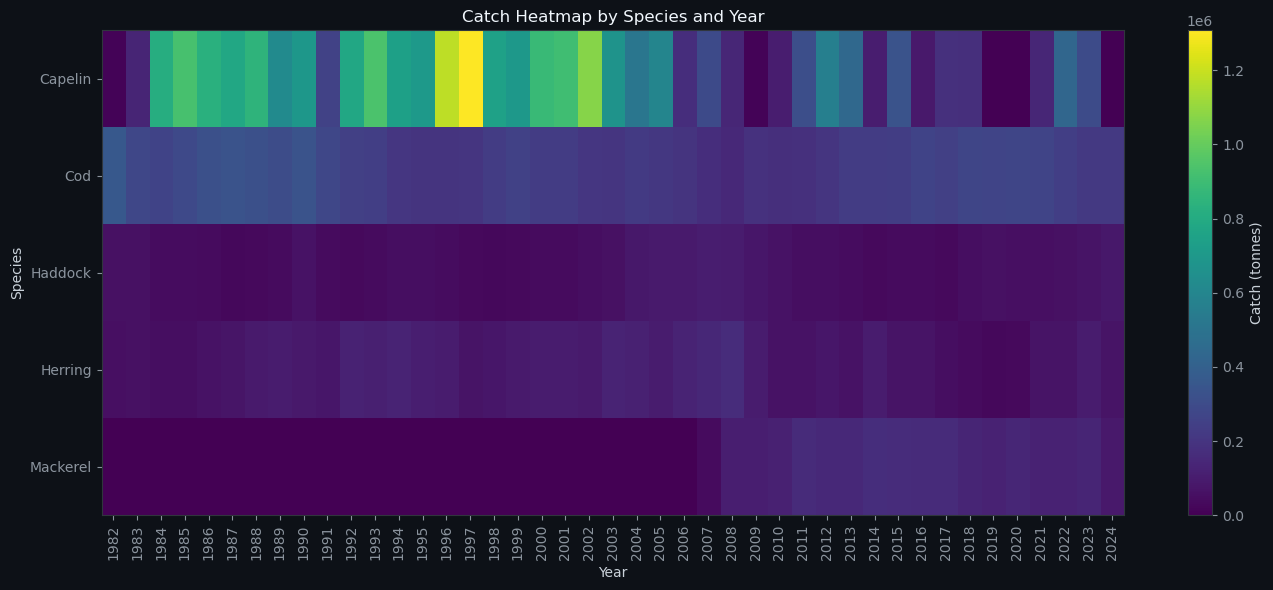

In [54]:
heatmap_data = (
    df_yearly
    .groupby(["Species", "Year"])["Quantity"]
    .sum()
    .unstack()
)

plt.figure(figsize=(14, 6))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Catch (tonnes)")

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=90
)

plt.title("Catch Heatmap by Species and Year")
plt.xlabel("Year")
plt.ylabel("Species")

plt.tight_layout()
plt.show()

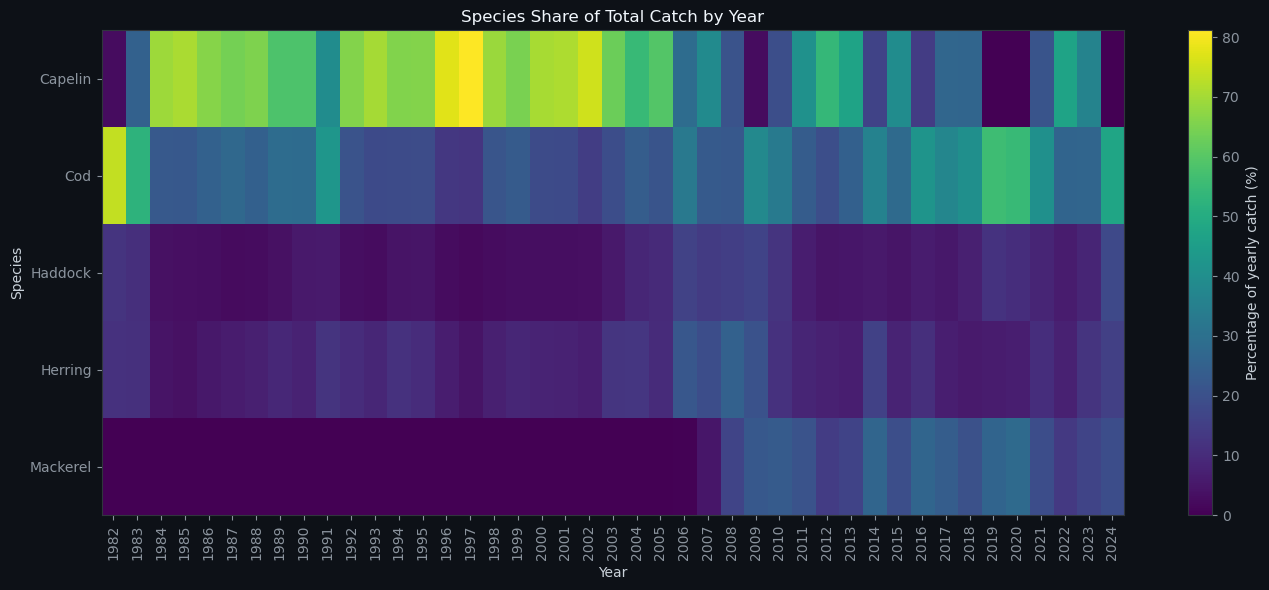

In [55]:
# Total catch per year
year_totals = (
    df_yearly
    .groupby("Year")["Quantity"]
    .sum()
)

# Catch by species and year
species_yearly = (
    df_yearly
    .groupby(["Species", "Year"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
)

# Convert to percentages
heatmap_pct = species_yearly.divide(year_totals, axis=1) * 100

plt.figure(figsize=(14, 6))

plt.imshow(
    heatmap_pct,
    aspect="auto"
)

plt.colorbar(label="Percentage of yearly catch (%)")

plt.yticks(
    range(len(heatmap_pct.index)),
    heatmap_pct.index
)

plt.xticks(
    range(len(heatmap_pct.columns)),
    heatmap_pct.columns,
    rotation=90
)

plt.title("Species Share of Total Catch by Year")
plt.xlabel("Year")
plt.ylabel("Species")

plt.tight_layout()
plt.show()

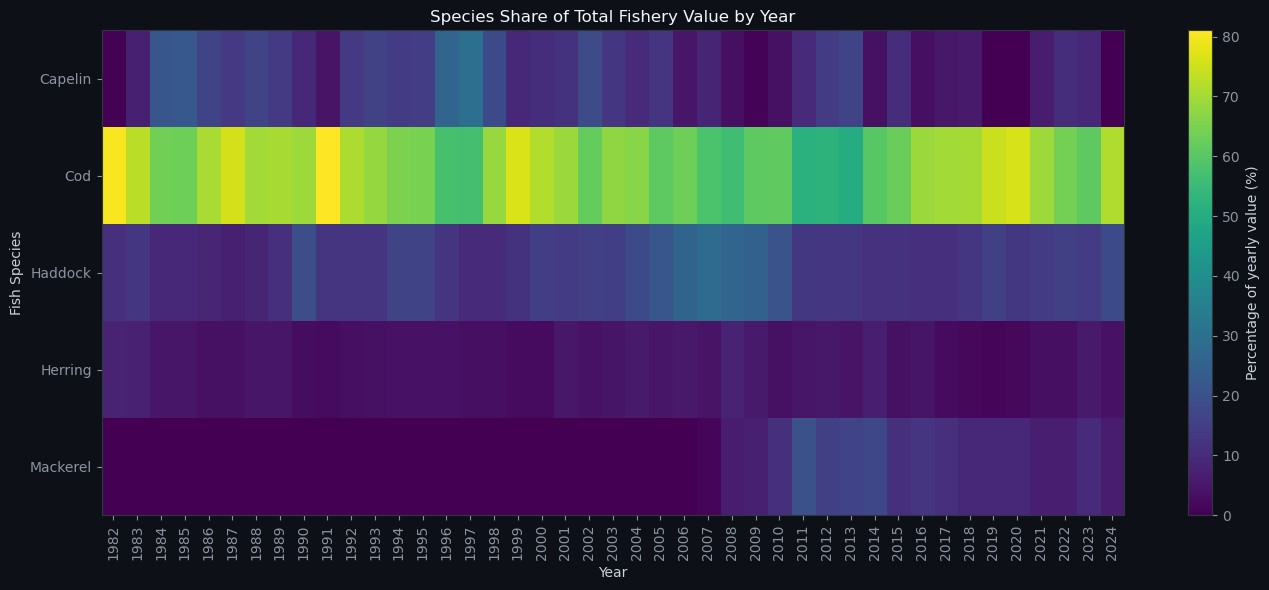

In [56]:
# Total value per year
year_totals_value = (
    df_yearly
    .groupby("Year")["Value"]
    .sum()
)

# Value by species and year
species_value_yearly = (
    df_yearly
    .groupby(["Species", "Year"])["Value"]
    .sum()
    .unstack(fill_value=0)
)

# Convert to percentages
heatmap_value_pct = (
    species_value_yearly
    .divide(year_totals_value, axis=1)
    * 100
)

plt.figure(figsize=(14, 6))

plt.imshow(
    heatmap_value_pct,
    aspect="auto"
)

plt.colorbar(label="Percentage of yearly value (%)")

plt.yticks(
    range(len(heatmap_value_pct.index)),
    heatmap_value_pct.index
)

plt.xticks(
    range(len(heatmap_value_pct.columns)),
    heatmap_value_pct.columns,
    rotation=90
)

plt.title("Species Share of Total Fishery Value by Year")
plt.xlabel("Year")
plt.ylabel("Fish Species")

plt.tight_layout()
plt.show()

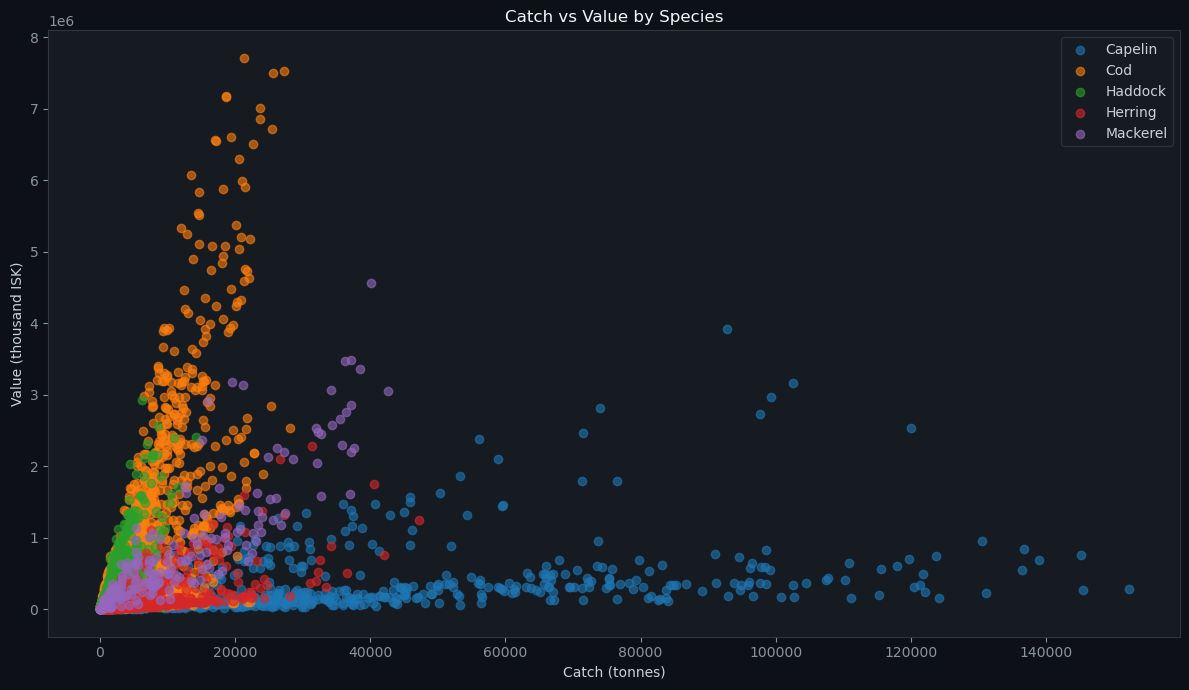

In [57]:
plt.figure(figsize=(12, 7))

species = df_yearly["Species"].unique()

for s in species:
    subset = df_yearly[df_yearly["Species"] == s]

    plt.scatter(
        subset["Quantity"],
        subset["Value"],
        alpha=0.6,
        label=s
    )

plt.title("Catch vs Value by Species")
plt.xlabel("Catch (tonnes)")
plt.ylabel("Value (thousand ISK)")

plt.legend()
plt.tight_layout()
plt.show()

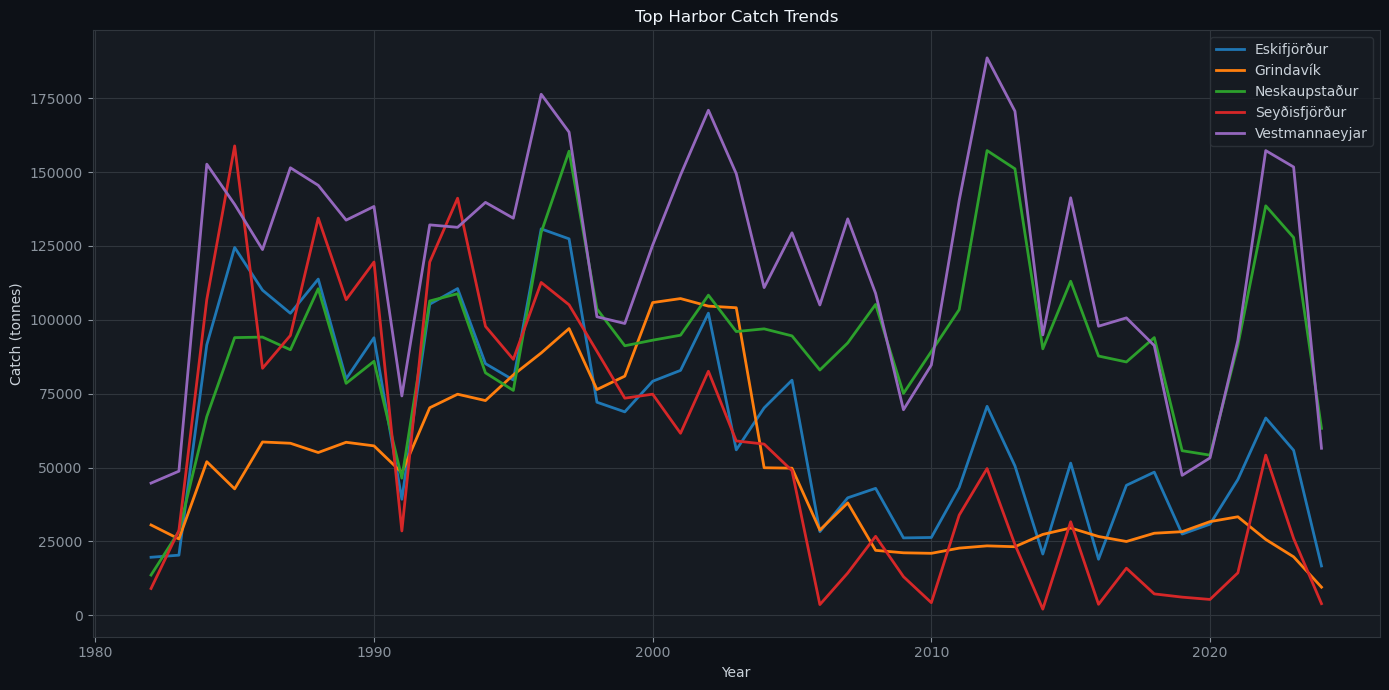

In [58]:
top5 = (
    df_yearly
    .groupby("Port")["Quantity"]
    .sum()
    .nlargest(5)
    .index
)

harbor_trends = (
    df_yearly[df_yearly["Port"].isin(top5)]
    .groupby(["Year", "Port"])["Quantity"]
    .sum()
    .unstack()
)

plt.figure(figsize=(14, 7))

for col in harbor_trends.columns:
    plt.plot(
        harbor_trends.index,
        harbor_trends[col],
        linewidth=2,
        label=col
    )

plt.title("Top Harbor Catch Trends")
plt.xlabel("Year")
plt.ylabel("Catch (tonnes)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Make .csv files

In [59]:
# Create csv files from the two dataframes
combined_df.to_csv("combined_fish_data.csv", index=False)
df_yearly.to_csv("yearly_fish_data.csv", index=False)

## Grindavík: From Stable Fishing Hub to Volcanic Uncertainty

For decades, Grindavík was one of Iceland’s most consistent fishing ports and saw a consistent rise until a great decline in capelin catches began in 2004. While several major harbors experienced large fluctuations in landings over time, Grindavík maintained relatively stable catch volumes after the capelin decline. This stability reflected the town’s strong fishing infrastructure and its importance within Iceland’s fisheries sector.

After 2021, however, the data shows a sharp and sustained decline in landings at Grindavík. Unlike earlier downturns that were primarily linked to changing fish stocks or quota allocations, this decline coincides with the volcanic activity on the Reykjanes Peninsula. Beginning in 2021 and intensifying in later years, repeated eruptions and seismic activity disrupted daily life, infrastructure, and economic activity in the region. The fisheries data suggests that these natural events may have significantly affected the operation of Grindavík as a landing harbor, marking a dramatic shift in the town’s long-standing role in Icelandic fisheries.

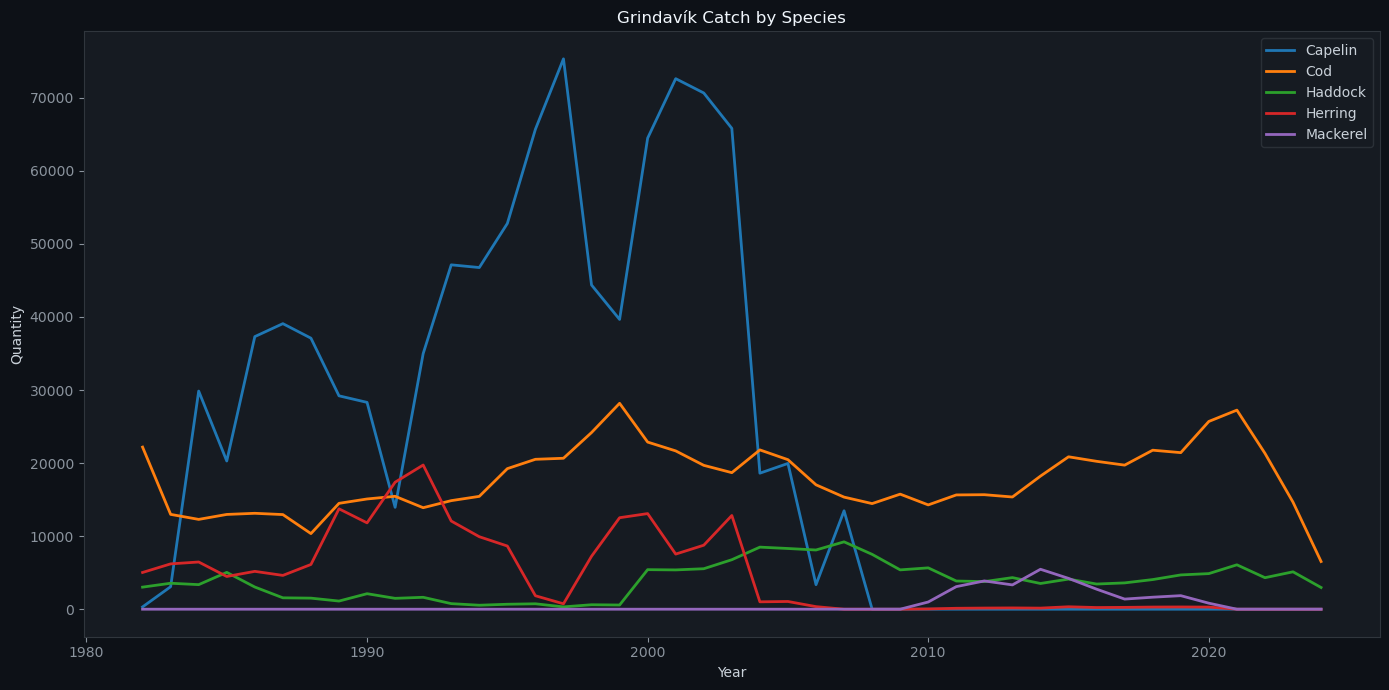

In [60]:
grindavik = df_yearly[df_yearly["Port"] == "Grindavík"]

species_port = (
    grindavik
    .groupby(["Year", "Species"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14,7))

for col in species_port.columns:
    plt.plot(
        species_port.index,
        species_port[col],
        linewidth=2,
        label=col
    )

#plt.axvline(2004, linestyle="--")
plt.title("Grindavík Catch by Species")
plt.xlabel("Year")
plt.ylabel("Quantity")
plt.legend()

plt.tight_layout()
plt.show()

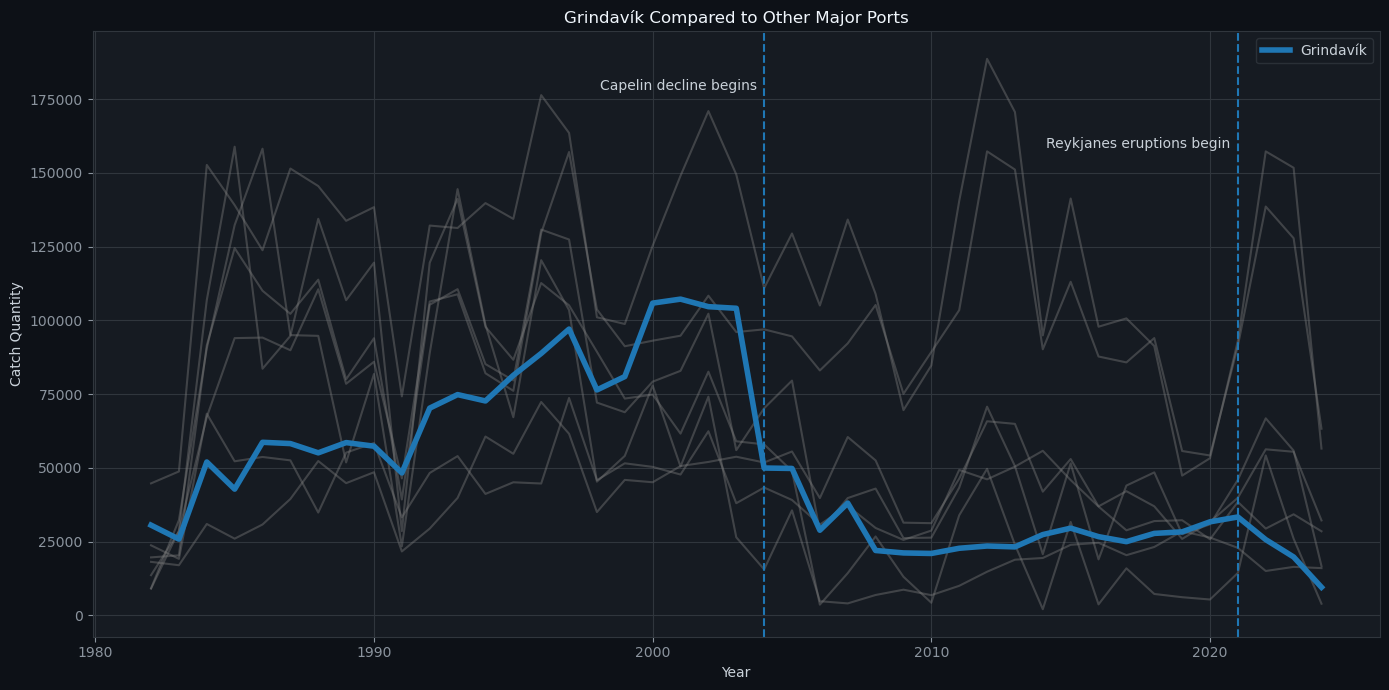

In [61]:
top_ports = (
    df_yearly
    .groupby("Port")["Quantity"]
    .sum()
    .nlargest(8)
    .index
)

top_df = df_yearly[df_yearly["Port"].isin(top_ports)]

pivot_ports = (
    top_df
    .groupby(["Year", "Port"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 7))

for port in pivot_ports.columns:
    if port != "Grindavík":
        plt.plot(
            pivot_ports.index,
            pivot_ports[port],
            color="gray",
            alpha=0.4,
            linewidth=1.5
        )

plt.plot(
    pivot_ports.index,
    pivot_ports["Grindavík"],
    linewidth=4,
    label="Grindavík"
)

plt.axvline(2004, linestyle="--")
plt.axvline(2021, linestyle="--")

plt.text(2004 - 5.9, plt.ylim()[1]*0.9, "Capelin decline begins")
plt.text(2021 -6.9, plt.ylim()[1]*0.8, "Reykjanes eruptions begin")

plt.title("Grindavík Compared to Other Major Ports")
plt.xlabel("Year")
plt.ylabel("Catch Quantity")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

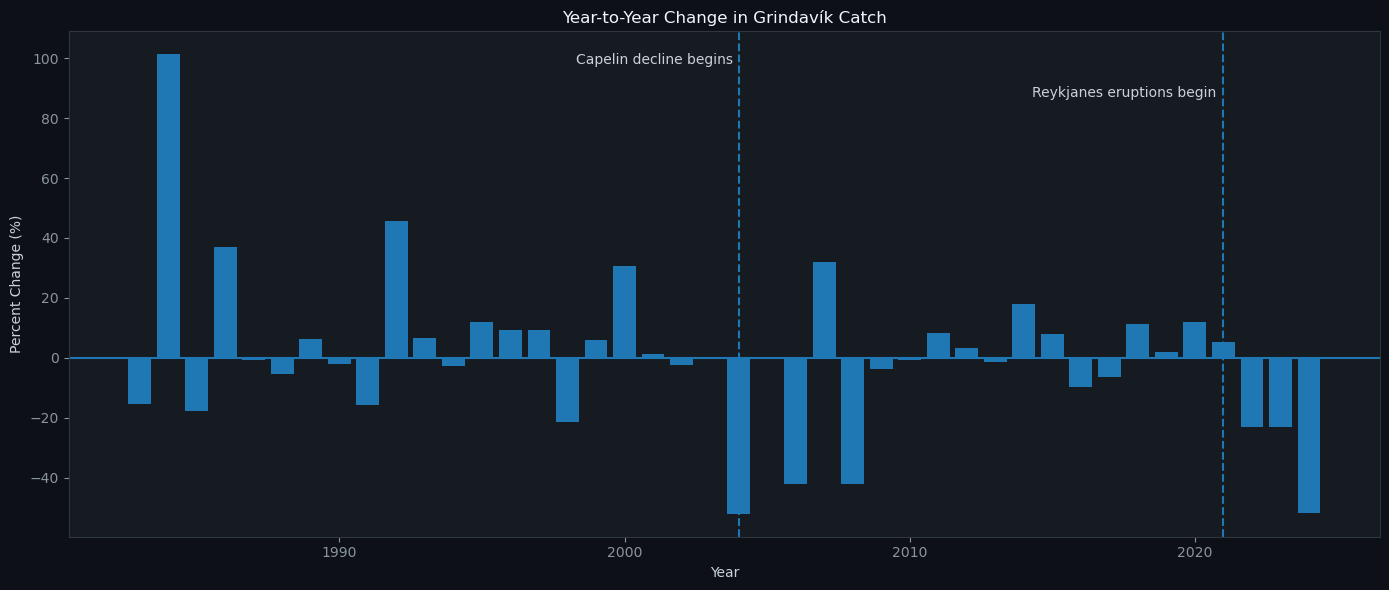

In [62]:
grindavik = (
    df_yearly[df_yearly["Port"] == "Grindavík"]
    .groupby("Year")["Quantity"]
    .sum()
    .sort_index()
)

pct_change = grindavik.pct_change() * 100

plt.figure(figsize=(14, 6))

plt.bar(
    pct_change.index,
    pct_change.values
)

plt.axhline(0)

plt.axvline(2004, linestyle="--")
plt.axvline(2021, linestyle="--")

plt.text(2004 - 5.7, plt.ylim()[1]*0.9, "Capelin decline begins")
plt.text(2021 - 6.7, plt.ylim()[1]*0.8, "Reykjanes eruptions begin")

plt.title("Year-to-Year Change in Grindavík Catch")
plt.xlabel("Year")
plt.ylabel("Percent Change (%)")

plt.tight_layout()
plt.show()

## Save plots for each year

In [63]:
# import os
# import matplotlib.pyplot as plt
# import pandas as pd

# # Create output folder
# os.makedirs("monthly_plots", exist_ok=True)

# # Month labels
# month_names = [
#     "Jan", "Feb", "Mar", "Apr", "May", "Jun",
#     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
# ]

# # Get all years
# years = sorted(combined_df["Year"].unique())

# # Loop through years
# for year in years:

#     # Filter for current year
#     df_year = combined_df[combined_df["Year"] == year]

#     # Sum monthly quantity by species
#     species_monthly = (
#         df_year
#         .groupby(["Month", "Species"])["Quantity"]
#         .sum()
#         .reset_index()
#     )

#     # Pivot for plotting
#     pivot_monthly = species_monthly.pivot(
#         index="Month",
#         columns="Species",
#         values="Quantity"
#     ).fillna(0)

#     # Ensure months are in correct order
#     pivot_monthly = pivot_monthly.reindex(range(1, 13), fill_value=0)

#     # Create figure
#     plt.figure(figsize=(14, 7))

#     # Plot each species
#     for species in pivot_monthly.columns:
#         plt.plot(
#             pivot_monthly.index,
#             pivot_monthly[species],
#             linewidth=2,
#             label=species
#         )

#     # X-axis formatting
#     plt.xticks(range(1, 13), month_names)

#     # Labels and title
#     plt.title(f"Monthly Catch by Species ({year})")
#     plt.xlabel("Month")
#     plt.ylabel("Catch Quantity (tonnes)")
#     plt.grid(True)

#     plt.legend()

#     # Save plot
#     plt.tight_layout()
#     plt.savefig(
#         f"monthly_plots/monthly_catch_{year}.png",
#         dpi=300
#     )

#     # Close figure to avoid memory buildup
#     plt.close()

In [64]:

# # Create output folder
# os.makedirs("monthly_plots", exist_ok=True)

# # Month labels
# month_names = [
#     "Jan", "Feb", "Mar", "Apr", "May", "Jun",
#     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
# ]

# # Get all years
# years = sorted(combined_df["Year"].unique())

# # Loop through years
# for year in years:

#     # Filter for current year
#     df_year = combined_df[combined_df["Year"] == year]

#     # Sum monthly quantity by species
#     species_monthly = (
#         df_year
#         .groupby(["Month", "Species"])["Value"]
#         .sum()
#         .reset_index()
#     )

#     # Pivot for plotting
#     pivot_monthly = species_monthly.pivot(
#         index="Month",
#         columns="Species",
#         values="Value"
#     ).fillna(0)

#     # Ensure months are in correct order
#     pivot_monthly = pivot_monthly.reindex(range(1, 13), fill_value=0)

#     # Create figure
#     plt.figure(figsize=(14, 7))

#     # Plot each species
#     for species in pivot_monthly.columns:
#         plt.plot(
#             pivot_monthly.index,
#             pivot_monthly[species],
#             linewidth=2,
#             label=species
#         )

#     # X-axis formatting
#     plt.xticks(range(1, 13), month_names)

#     # Labels and title
#     plt.title(f"Monthly Value by Species ({year})")
#     plt.xlabel("Month")
#     plt.ylabel("Catch Value (thousand ISK)")
#     plt.grid(True)

#     plt.legend()

#     # Save plot
#     plt.tight_layout()
#     plt.savefig(
#         f"monthly_plots/monthly_value_{year}.png",
#         dpi=300
#     )

#     # Close figure to avoid memory buildup
#     plt.close()

In [65]:
# import os
# import matplotlib.pyplot as plt
# import pandas as pd

# # Create output folder
# os.makedirs("monthly_plots", exist_ok=True)

# # Get all years
# years = sorted(combined_df["Year"].unique())

# # Loop through years
# for year in years:

#     # Filter current year
#     df_year = combined_df[combined_df["Year"] == year]

#     # Top 10 ports by yearly quantity
#     top10_ports = (
#         df_year
#         .groupby("Port", as_index=False)["Quantity"]
#         .sum()
#         .sort_values("Quantity", ascending=False)
#         .head(10)
#     )

#     # Create figure
#     plt.figure(figsize=(12, 6))

#     # Bar chart
#     plt.bar(
#         top10_ports["Port"],
#         top10_ports["Quantity"]
#     )

#     # Labels and title
#     plt.title(f"Top 10 Ports by Catch Quantity ({year})")
#     plt.xlabel("Port")
#     plt.ylabel("Catch Quantity (tonnes)")

#     # Rotate x labels
#     plt.xticks(rotation=45)

#     # Save figure
#     plt.tight_layout()
#     plt.savefig(
#         f"monthly_plots/top10ports_{year}.png",
#         dpi=300
#     )

#     # Close figure
#     plt.close()

In [69]:
import os

# --- Theme colors  ---
BG = "#0d1117"
PANEL = "#161b22"
GRID = "#30363d"
TEXT = "#c9d1d9"
MUTED = "#8b949e"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": PANEL,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": TEXT,
    "axes.titlecolor": "#f0f6fc",
    "grid.color": GRID,
    "legend.facecolor": PANEL,
    "legend.edgecolor": GRID,
    "font.family": "DejaVu Sans"
})

# --- Original-style distinct matplotlib colors ---
SPECIES_COLORS = {
    "Capelin": "#1f77b4",        # blue
    "Cod": "#ff7f0e",   # orange
    "Haddock": "#2ca02c",   # green
    "Herring": "#d62728",   # red
    "Mackerel": "#9467bd",  # purple
}

# Create folder
os.makedirs("monthly_plots", exist_ok=True)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

years = sorted(combined_df["Year"].unique())

for year in years:

    df_year = combined_df[combined_df["Year"] == year]

    species_monthly = (
        df_year
        .groupby(["Month", "Species"])["Quantity"]
        .sum()
        .reset_index()
    )

    pivot_monthly = species_monthly.pivot(
        index="Month",
        columns="Species",
        values="Quantity"
    ).fillna(0)

    pivot_monthly = pivot_monthly.reindex(range(1, 13), fill_value=0)

    plt.figure(figsize=(14, 7))

    for species in pivot_monthly.columns:

        plt.plot(
            pivot_monthly.index,
            pivot_monthly[species],
            linewidth=2.8,
            color=SPECIES_COLORS.get(species, "#58a6ff"),
            label=species
        )

    plt.xticks(range(1, 13), month_names)

    plt.title(
        f"Monthly Catch by Species ({year})",
        fontsize=20,
        pad=18
    )

    plt.xlabel("Month")
    plt.ylabel("Catch Quantity (tonnes)")

    plt.grid(alpha=0.45)

    legend = plt.legend(framealpha=1)

    for text in legend.get_texts():
        text.set_color(TEXT)

    plt.tight_layout()

    plt.savefig(
        f"monthly_plots/monthly_catch_{year}.png",
        dpi=300,
        facecolor=BG
    )

    plt.close()

In [70]:
import os
import numpy as np

os.makedirs("monthly_plots", exist_ok=True)

years = sorted(combined_df["Year"].unique())

for year in years:

    df_year = combined_df[combined_df["Year"] == year]

    top10_ports = (
        df_year
        .groupby("Port", as_index=False)["Quantity"]
        .sum()
        .sort_values("Quantity", ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12, 6))

    bars = plt.bar(
        top10_ports["Port"],
        top10_ports["Quantity"],
        color=ACCENT,
        edgecolor="#79c0ff",
        linewidth=1.2
    )

    # subtle glow effect
    for bar in bars:
        bar.set_alpha(0.9)

    plt.title(
        f"Top 10 Ports by Catch Quantity ({year})",
        fontsize=20,
        pad=18
    )

    plt.xlabel("Port")
    plt.ylabel("Catch Quantity (tonnes)")

    plt.xticks(rotation=35)

    plt.grid(axis="y", alpha=0.35)

    plt.tight_layout()

    plt.savefig(
        f"monthly_plots/top10ports_{year}.png",
        dpi=300,
        facecolor=BG
    )

    plt.close()

In [68]:
# Create folder
os.makedirs("monthly_plots", exist_ok=True)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

years = sorted(combined_df["Year"].unique())

for year in years:

    df_year = combined_df[combined_df["Year"] == year]

    species_monthly = (
        df_year
        .groupby(["Month", "Species"])["Value"]
        .sum()
        .reset_index()
    )

    pivot_monthly = species_monthly.pivot(
        index="Month",
        columns="Species",
        values="Value"
    ).fillna(0)

    pivot_monthly = pivot_monthly.reindex(range(1, 13), fill_value=0)

    plt.figure(figsize=(14, 7))

    for species in pivot_monthly.columns:

        plt.plot(
            pivot_monthly.index,
            pivot_monthly[species],
            linewidth=2.8,
            color=SPECIES_COLORS.get(species, "#58a6ff"),
            label=species
        )

    plt.xticks(range(1, 13), month_names)

    plt.title(
        f"Monthly Fishery Value by Species ({year})",
        fontsize=20,
        pad=18
    )

    plt.xlabel("Month")
    plt.ylabel("Value (thousand ISK)")

    plt.grid(alpha=0.45)

    legend = plt.legend(framealpha=1)

    for text in legend.get_texts():
        text.set_color(TEXT)

    plt.tight_layout()

    plt.savefig(
        f"monthly_plots/monthly_value_{year}.png",
        dpi=300,
        facecolor=BG
    )

    plt.close()